In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# ==========================================
# 1. Load & Inspect Data
# ==========================================
# The file is in the same folder.
df = pd.read_csv('SuperMarket Analysis.csv')

print("--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Descriptive Statistics ---")
print(df.describe())


--- First 5 Rows ---
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428   Alex     Yangon        Member  Female   
1  226-31-3081   Giza  Naypyitaw        Normal  Female   
2  631-41-3108   Alex     Yangon        Normal  Female   
3  123-19-1176   Alex     Yangon        Member  Female   
4  373-73-7910   Alex     Yangon        Member  Female   

             Product line  Unit price  Quantity   Tax 5%     Sales       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

          Time      Payment    cogs  gross margin percentage  gross income  \
0   1:08:00 PM      Ewallet  522.83                 4.761905     

In [11]:
# ==========================================
# 2. Data Cleaning
# ==========================================
# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# Adjust Datatypes with explicit formats to avoid warnings
# Format matches: 1/5/2019
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Format matches: 1:08:00 PM
df['Time_DT'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p')

# Extract Hour and Month for better analysis
df['Hour'] = df['Time_DT'].dt.hour
df['Month'] = df['Date'].dt.month

print("\nData cleaning complete. Date/Time converted and Hour/Month columns added.")



Missing Values:
 Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Data cleaning complete. Date/Time converted and Hour/Month columns added.


In [12]:
# ==========================================
# 3 & 4. Exploratory & Revenue Analysis
# ==========================================
# Calculate core metrics for report questions
branch_sales = df.groupby('Branch')['Sales'].sum().sort_values(ascending=False)
customer_stats = df.groupby('Customer type')['Sales'].sum()
product_rating_stats = df.groupby('Product line')['Rating'].mean().sort_values(ascending=False)
payment_usage = df['Payment'].value_counts()

# Correlation Analysis (Numeric columns)
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

print("\n--- Revenue by Branch ---")
print(branch_sales)



--- Revenue by Branch ---
Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64


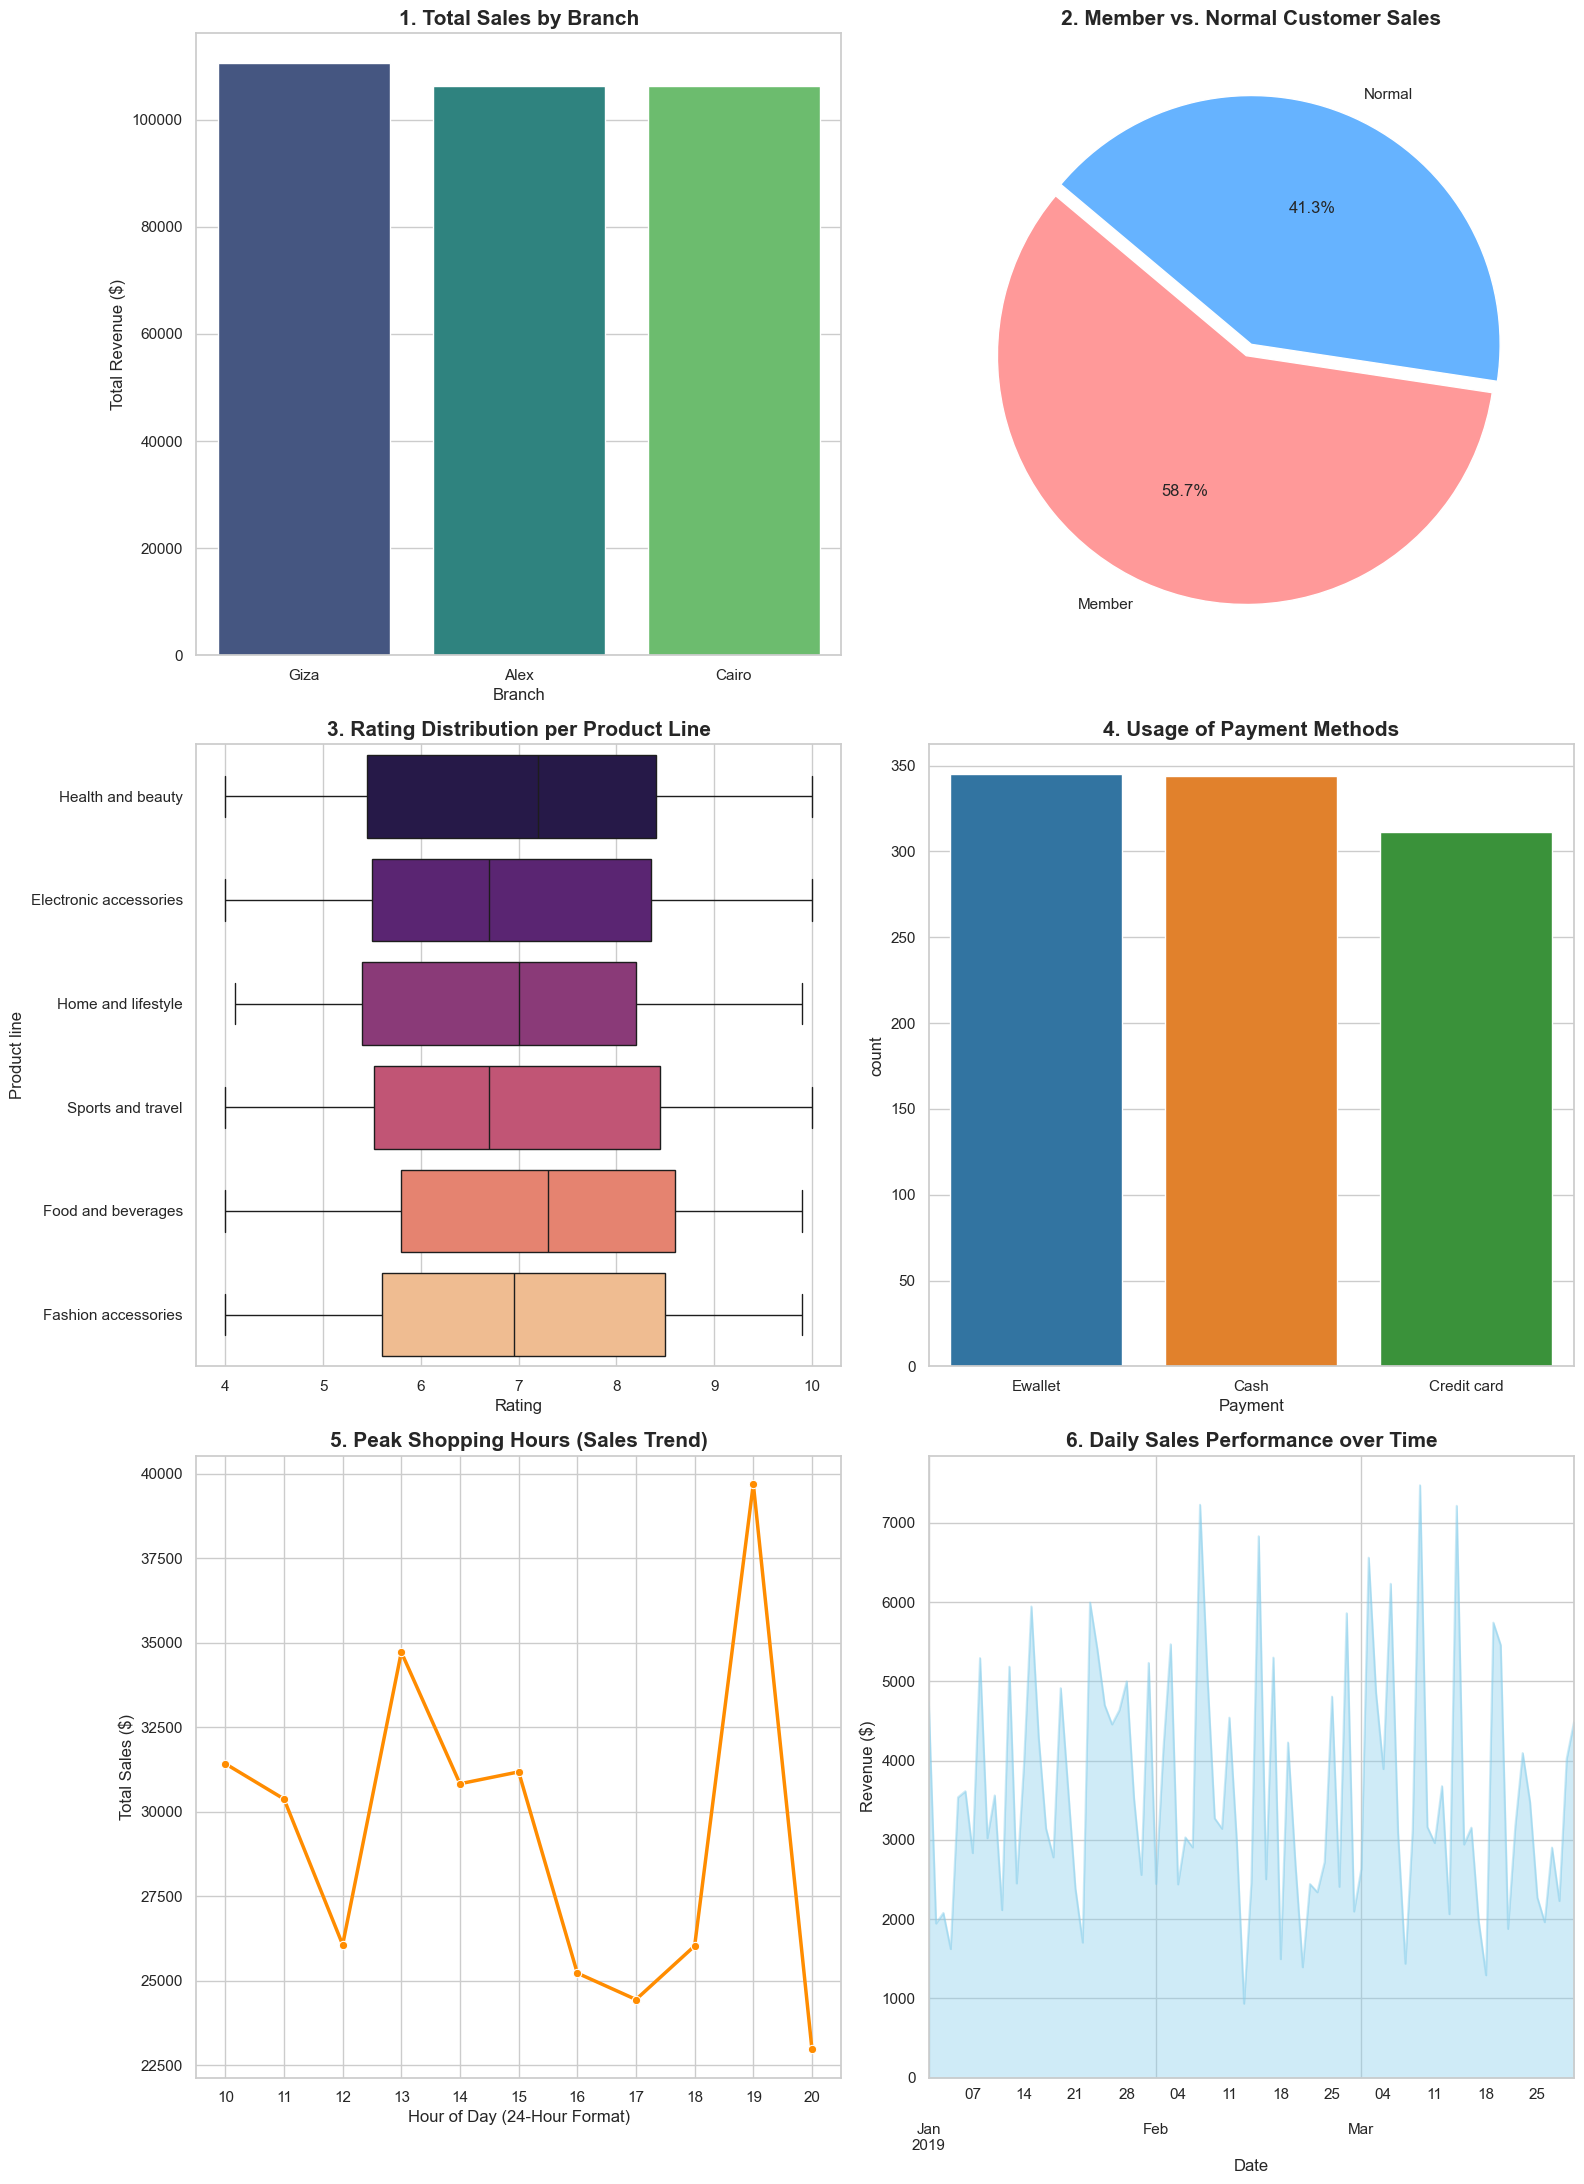

In [13]:
# ==========================================
# 5. Visualization
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 22))

# 1. Total Sales by Branch (Bar Chart)
plt.subplot(3, 2, 1)
sns.barplot(x=branch_sales.index, y=branch_sales.values, hue=branch_sales.index, palette="viridis", legend=False)
plt.title('1. Total Sales by Branch', fontsize=15, fontweight='bold')
plt.ylabel('Total Revenue ($)')

# 2. Sales Distribution by Customer Type (Pie Chart)
plt.subplot(3, 2, 2)
customer_stats.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140, explode=[0.05, 0])
plt.title('2. Member vs. Normal Customer Sales', fontsize=15, fontweight='bold')
plt.ylabel('')

# 3. Customer Ratings by Product Line (Box Plot)
plt.subplot(3, 2, 3)
sns.boxplot(x='Rating', y='Product line', data=df, hue='Product line', palette="magma", legend=False)
plt.title('3. Rating Distribution per Product Line', fontsize=15, fontweight='bold')

# 4. Most Used Payment Methods (Count Plot)
plt.subplot(3, 2, 4)
sns.countplot(x='Payment', data=df, hue='Payment', palette="tab10", legend=False)
plt.title('4. Usage of Payment Methods', fontsize=15, fontweight='bold')

# 5. NEW: Hourly Sales Trend (Line Chart)
plt.subplot(3, 2, 5)
hourly_sales = df.groupby('Hour')['Sales'].sum()
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, marker='o', color='darkorange', linewidth=2.5)
plt.title('5. Peak Shopping Hours (Sales Trend)', fontsize=15, fontweight='bold')
plt.xlabel('Hour of Day (24-Hour Format)')
plt.ylabel('Total Sales ($)')
plt.xticks(range(int(hourly_sales.index.min()), int(hourly_sales.index.max()) + 1))

# 6. Daily Sales Performance (Area Chart)
plt.subplot(3, 2, 6)
df.groupby('Date')['Sales'].sum().plot(kind='area', color='skyblue', alpha=0.4)
plt.title('6. Daily Sales Performance over Time', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')

plt.tight_layout()
plt.show()
